In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("group_20_1.csv")

target = "Amyl"

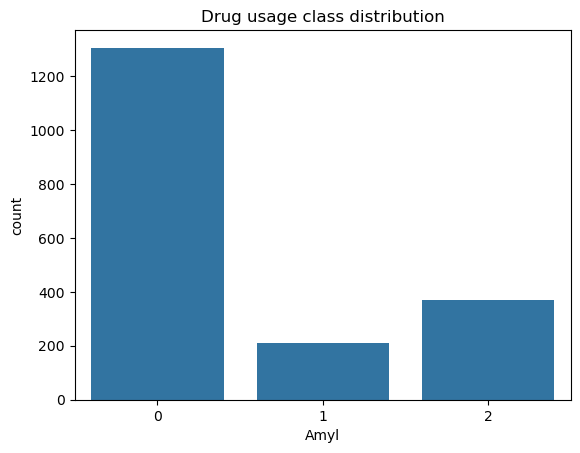

In [2]:
sns.countplot(x=target, data=df)
plt.title("Drug usage class distribution")
plt.show()

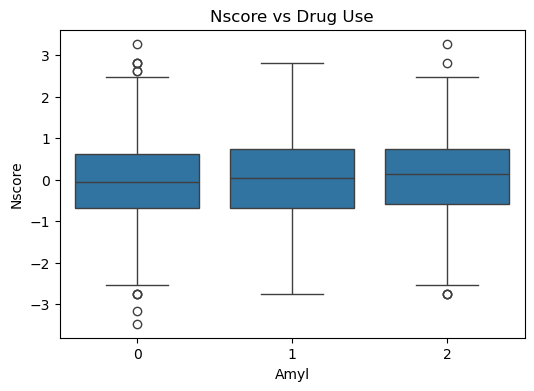

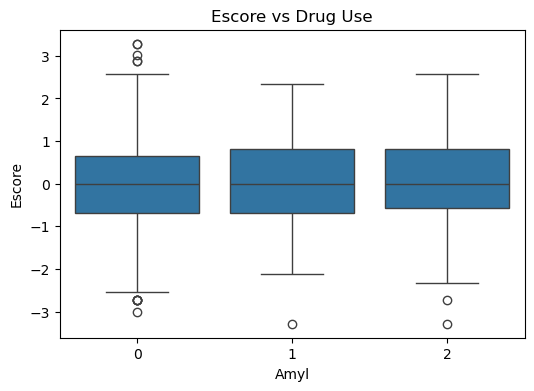

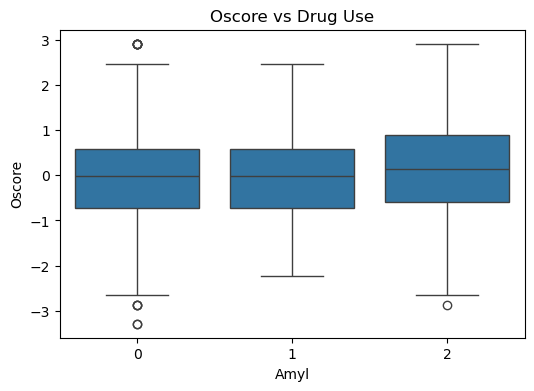

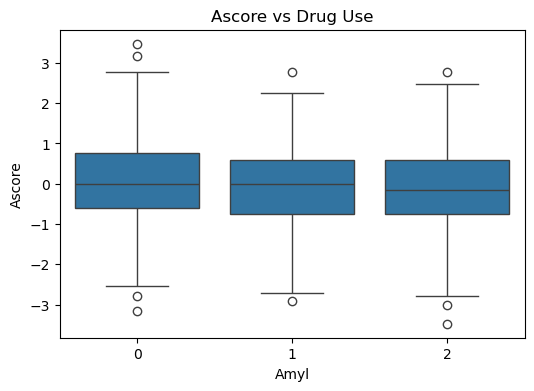

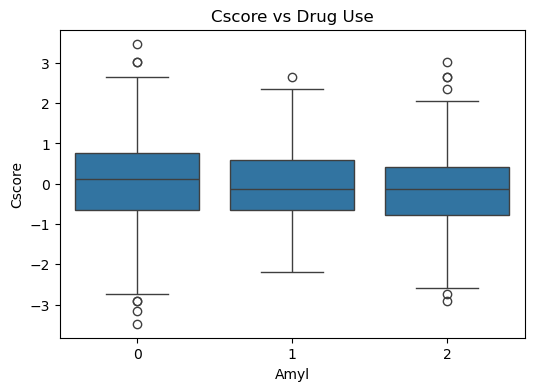

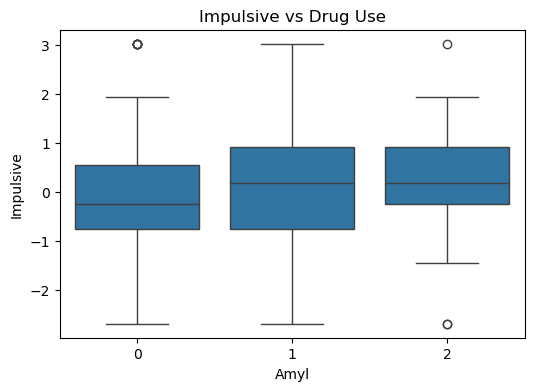

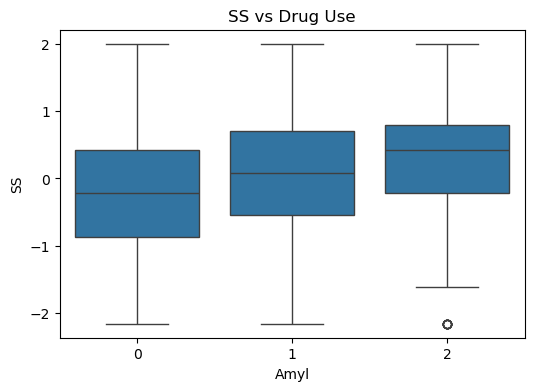

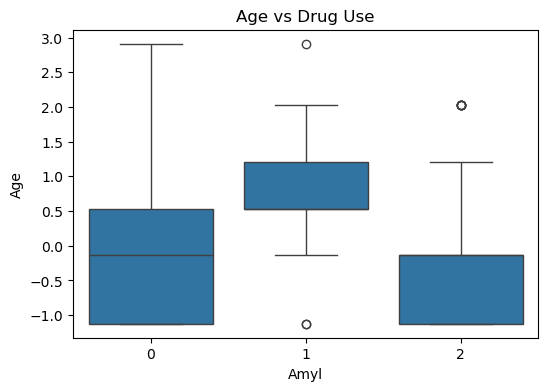

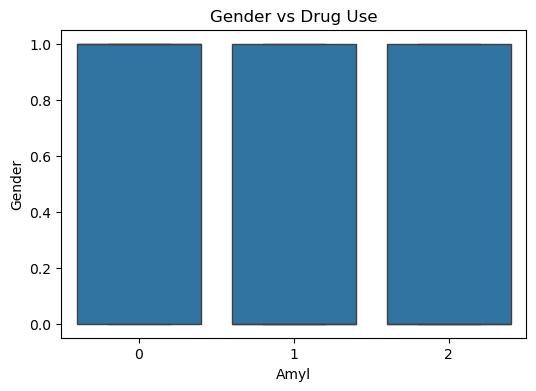

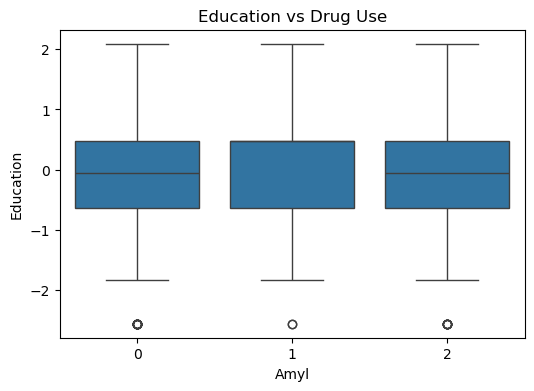

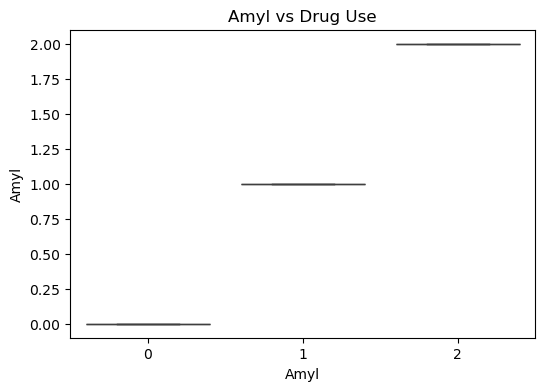

In [172]:
features = [
"Nscore","Escore","Oscore","Ascore","Cscore",
"Impulsive","SS","Age","Gender","Education","Amyl"
]

for col in features:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=col, data=df)
    
    plt.title(f"{col} vs Drug Use")
    plt.show()

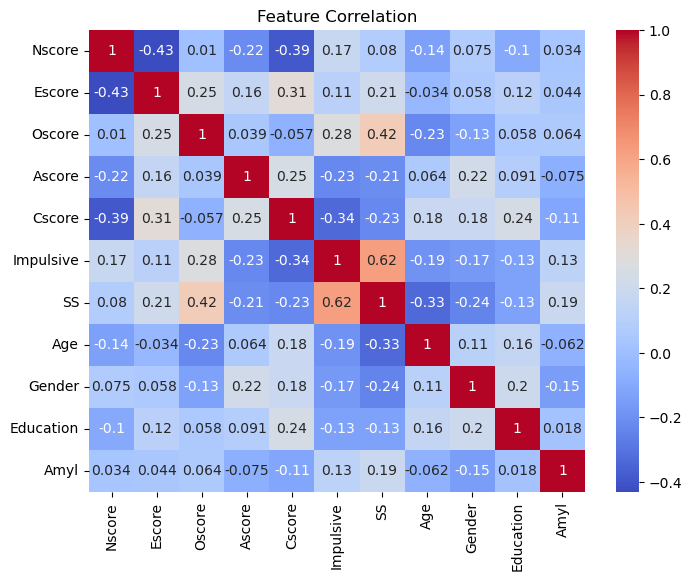

In [173]:
corr = df[features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Feature Correlation")
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
#测试
# temp=resample_pytorch(df,"Amyl")
# len(set(temp[temp.iloc[:,13]==0]["ID"]))
# df[df.iloc[:,13]==1]

177

In [3]:

X=df.iloc[:,1:12]
# X.iloc[:,3:5]=df.iloc[:,14:16].copy()
X=X.values
y=df.iloc[:,13].values
n_features=X.shape[-1]
X

array([[ 0.52756593,  1.        , -0.05833058, ..., -0.91934136,
        -0.00628115, -0.23510842],
       [-0.1288537 ,  0.        ,  2.09319986, ...,  0.76336078,
        -0.14277542, -0.75297646],
       [ 0.52756593,  0.        , -0.05833058, ..., -1.62524491,
        -1.01690228, -1.45365042],
       ...,
       [-0.1288537 ,  1.        ,  0.48270524, ..., -1.77677285,
        -1.38844104,  0.54762541],
       [-1.12350447,  1.        , -0.6394053 , ..., -1.62524491,
        -2.57977769,  1.34669787],
       [-1.12350447,  0.        , -0.6394053 , ...,  1.1174608 ,
         0.41747077,  0.91587828]], shape=(1885, 11))

In [4]:
print(X.shape)
print(np.unique(y, return_counts=True))

(1885, 11)
(array([0, 1, 2]), array([1305,  210,  370]))


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.3,
    random_state=42,
    stratify=y)
type(X_test)


numpy.ndarray

In [6]:
#标准化
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
classes = np.unique(y_train)
y_train
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
print(weights)
weights = torch.tensor(weights, dtype=torch.float32)

[0.48156261 2.99092971 1.6975547 ]


In [18]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
print(X_train.shape,y_train.shape,X_test.shape)
np.unique(y_train,return_counts=True)
type(y_train)

torch.Size([1319, 11]) torch.Size([1319, 1, 1]) torch.Size([566, 11])


C:\Users\29583\AppData\Local\Temp\ipykernel_10032\1333022195.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\29583\AppData\Local\Temp\ipykernel_10032\1333022195.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\29583\AppData\Local\Temp\ipykernel_10032\1333022195.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
C:\Users\29583\AppData\Local\Temp\i

torch.Tensor

In [19]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [20]:
#模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)   
        )
    def forward(self, x):
        return self.net(x)

In [21]:
model=Net()
criterion = nn.BCEWithLogitsLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.005)

In [22]:
#训练模块
from collections import deque
epochs = 100
pre_loss=deque(maxlen=5)
pre=0
for epoch in range(epochs):

    model.train()
    correct = 0
    total = 0
    total_loss = 0
    for X_batch, y_batch in train_loader:
        

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    pre_loss.append(abs(pre-total_loss))
    pre=total_loss
    accuracy = correct / total
    # if accuracy>0.9:
    #     break
    #早停判断
    if sum(pre_loss)<0.1:
        break
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Acurracy:{accuracy:4f}")


ValueError: Target size (torch.Size([64, 1, 1])) must be the same as input size (torch.Size([64, 1]))

In [192]:
model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())
ans=[0,0,0]
for x in preds:
    ans[x]+=1
ans

[285, 100, 181]

In [187]:
print(np.unique(y_test, return_counts=True))
type(y_test)

(array([0, 1, 2]), array([392,  63, 111]))


torch.Tensor

In [188]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(true, preds)

print("Test Accuracy:", acc)

Test Accuracy: 0.5565371024734982


In [193]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, preds))

[[220  55 117]
 [ 26  23  14]
 [ 39  22  50]]
